(mmm_lift_test_backend)=

# Deep Dive: How `add_lift_test_measurements` Works

## Introduction

This notebook provides an in-depth exploration of the **backend implementation** of MMM lift test calibration in **pymc-marketing**. While the {ref}`mmm_lift_test` and {ref}`mmm_geolift_calibration` notebooks demonstrate *how to use* lift tests to improve your MMM, this notebook reveals *how it works under the hood*.

:::{admonition} Prerequisites
:class: tip

Before diving into this notebook, we recommend reading:

- **{ref}`mmm_lift_test`**: Introduces lift test calibration and its benefits
- **{ref}`mmm_geolift_calibration`**: Shows geo-level lift test integration
- **Basic understanding of PyMC**: Familiarity with PyMC models and distributions
:::

## What You'll Learn

By the end of this notebook, you'll understand:

1. **The mathematical framework** behind lift test calibration
2. **The data transformation pipeline** from raw lift test data to model observations
3. **How lift tests constrain saturation curves** through likelihood contributions
4. **The role of coordinate alignment** in mapping lift tests to model parameters
5. **How scaling and normalization** ensure lift tests use the same units as the model

## The Core Concept

The key insight behind lift test calibration is surprisingly elegant:

**A lift test measures the difference in outcomes between two spend levels.** The saturation function predicts this same difference. By adding the empirical lift measurement as an observed random variable, we constrain the saturation parameters to match real-world behavior.

Mathematically:

$$
\text{model\_estimated\_lift} = f_{\text{saturation}}(x + \Delta x) - f_{\text{saturation}}(x)
$$

$$
\Delta y_{\text{observed}} \sim \text{Distribution}(\mu = |\text{model\_estimated\_lift}|, \sigma = \sigma_{\text{lift}})
$$

Where:
- $x$ is the baseline spend level
- $\Delta x$ is the incremental spend change
- $\Delta y_{\text{observed}}$ is the measured lift from the experiment
- $\sigma_{\text{lift}}$ is the uncertainty in the lift measurement

## Notebook Structure

This notebook is organized into the following sections:

1. **Setup**: Load libraries and create synthetic data
2. **The High-Level Workflow**: How `add_lift_test_measurements` is called
3. **Data Transformation Pipeline**: Step-by-step breakdown of data processing
4. **Coordinate Alignment**: How lift tests map to model dimensions
5. **Saturation Observation Creation**: Building the likelihood term
6. **Visual Demonstration**: Interactive plots showing constraint effects
7. **Advanced Topics**: Time-varying saturation and multidimensional cases

Let's get started!

In [12]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.xtensor as ptx
from pytensor.xtensor import as_xtensor

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.lift_test import (
    add_saturation_observations,
    exact_row_indices,
    scale_lift_measurements,
)
from pymc_marketing.mmm.multidimensional import MMM

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

seed = sum(map(ord, "lift_test_backend_deep_dive"))
rng = np.random.default_rng(seed)

## 1. The High-Level Workflow

Let's start by reviewing the user-facing API. When you use lift tests in pymc-marketing, the workflow looks like this:

```python
# Step 1: Build the MMM
mmm = MMM(...)
mmm.build_model(X, y)

# Step 2: Add lift test measurements
df_lift_test = pd.DataFrame({
    'channel': ['channel_1'],
    'x': [100],           # Baseline spend
    'delta_x': [20],      # Incremental spend
    'delta_y': [15],      # Measured lift
    'sigma': [2]          # Uncertainty
})
mmm.add_lift_test_measurements(df_lift_test)

# Step 3: Fit the model
mmm.fit(X, y)
```

But what happens inside `add_lift_test_measurements`? Let's trace through the entire call stack.

## 2. Creating a Minimal Example

Let's create a minimal dataset to explore the backend step-by-step:

In [13]:
# Create simple synthetic data
n_dates = 30
dates = pd.date_range(start="2024-01-01", periods=n_dates, freq="W-MON")

# Two channels with different spend patterns
np.random.seed(42)
spend_ch1 = np.random.uniform(50, 150, n_dates)
spend_ch2 = np.random.uniform(30, 100, n_dates)

X = pd.DataFrame(
    {"date": pd.to_datetime(dates), "channel_1": spend_ch1, "channel_2": spend_ch2}
)

# Simple target: combination of both channels with some noise
true_contrib_ch1 = 50 * spend_ch1 / (spend_ch1 + 75)  # Logistic saturation
true_contrib_ch2 = 30 * spend_ch2 / (spend_ch2 + 50)
y = pd.Series(
    true_contrib_ch1 + true_contrib_ch2 + np.random.normal(0, 5, n_dates) + 100,
    name="y",
)

print("Data shape:", X.shape)
print("\nFirst few rows:")
print(X.head())
print("\nTarget summary:")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

Data shape: (30, 3)

First few rows:
        date   channel_1  channel_2
0 2024-01-01   87.454012  72.528140
1 2024-01-08  145.071431  41.936689
2 2024-01-15  123.199394  34.553612
3 2024-01-22  109.865848  96.421988
4 2024-01-29   65.601864  97.594242

Target summary:
y range: [133.5, 154.8]


Now let's build an MMM without lift tests first:

In [14]:
# Create MMM instance
mmm_no_lift = MMM(
    date_column="date",
    channel_columns=["channel_1", "channel_2"],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

# Build the model
mmm_no_lift.build_model(X, y)

print("Model built successfully!")

Model built successfully!


## 3. The Data Transformation Pipeline

Before lift test measurements can be added to the model, they must undergo several transformations. Let's trace through each step manually.

### Step 3.1: Input Data Format

First, let's define our lift test data:

In [15]:
# Define a lift test on channel_1
df_lift_test = pd.DataFrame(
    {
        "channel": ["channel_1"],  # Which channel was tested
        "x": [100.0],  # Baseline spend level
        "delta_x": [20.0],  # Incremental spend increase
        "delta_y": [8.0],  # Observed lift in target
        "sigma": [1.5],  # Uncertainty in the lift measurement
    }
)

print("Original lift test data:")
print(df_lift_test)
print("\nThis represents:")
print("- Increasing channel_1 spend from $100 to $120")
print("- Resulted in an observed lift of 8 units (±1.5)")

Original lift test data:
     channel      x  delta_x  delta_y  sigma
0  channel_1  100.0     20.0      8.0    1.5

This represents:
- Increasing channel_1 spend from $100 to $120
- Resulted in an observed lift of 8 units (±1.5)


### Step 3.2: Scaling to Model Units

The MMM internally scales both the features (X) and target (y). Lift tests must be transformed to these same scaled units. This is handled by `scale_lift_measurements`.

Let's see what scaling does:

In [16]:
# The multidimensional MMM uses internal scalers to transform data
# It creates transform functions on the fly rather than storing transformer objects
print("MMM has internal scalers:")
print(f"  - scalers object type: {type(mmm_no_lift.scalers)}")
print(f"  - Available scaler attributes: {dir(mmm_no_lift.scalers)}")

# Scale the lift test data using the MMM's internal methods
# These methods create transform functions on the fly
channel_transform = mmm_no_lift._make_channel_transform(df_lift_test)
target_transform = mmm_no_lift._make_target_transform(df_lift_test)

df_lift_test_scaled = scale_lift_measurements(
    df_lift_test=df_lift_test,
    channel_col="channel",
    channel_columns=mmm_no_lift.channel_columns,
    channel_transform=channel_transform,
    target_transform=target_transform,
    dim_cols=list(mmm_no_lift.dims),  # Empty list since no additional dims
)

print("\nScaled lift test data:")
print(df_lift_test_scaled)

print("\nScaling effects:")
for col in ["x", "delta_x", "delta_y", "sigma"]:
    original = df_lift_test[col].iloc[0]
    scaled = df_lift_test_scaled[col].iloc[0]
    ratio = scaled / original if original != 0 else np.nan
    print(f"{col:8s}: {original:8.3f} → {scaled:8.6f} (ratio: {ratio:.6f})")

MMM has internal scalers:
  - scalers object type: <class 'xarray.core.dataset.Dataset'>
  - Available scaler attributes: ['_HANDLED_TYPES', '__abs__', '__abstractmethods__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__class_getitem__', '__contains__', '__copy__', '__dask_graph__', '__dask_keys__', '__dask_layers__', '__dask_optimize__', '__dask_postcompute__', '__dask_postpersist__', '__dask_scheduler__', '__dask_tokenize__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__

### Understanding the Scaling Logic

The `scale_lift_measurements` function performs three key operations:

1. **Channel scaling** (`x` and `delta_x`): Applies the same scaling used for input features
2. **Target scaling** (`delta_y` and `sigma`): Applies the same scaling used for the target variable
3. **Handles multi-channel structure**: Properly reshapes data to match the model's expectation

**Note on Multidimensional MMM**: The multidimensional MMM class creates transform functions on the fly using `_make_channel_transform()` and `_make_target_transform()` methods, which internally use `self.scalers._channel` and `self.scalers._target`. This differs from the standard MMM class which stores `channel_transformer` and `target_transformer` objects.

This ensures that when we compare the model's predicted lift (in scaled units) to the observed lift (also in scaled units), we're comparing apples to apples.

## 4. Coordinate Alignment: Mapping Lift Tests to Model Parameters

A critical step is determining *which* model parameters should be used for each lift test. This is handled by `exact_row_indices`.

### Understanding Coordinates

PyMC models use **coordinates** to index multidimensional arrays. In an MMM:
- `channel` coordinate: indices for different media channels
- `date` coordinate (optional): indices for time-varying parameters
- `geo` coordinate (optional): indices for geographic regions

Let's see how this works:

In [17]:
# Inspect the model's coordinates
print("Model coordinates:")
for coord_name, coord_values in mmm_no_lift.model.coords.items():
    print(f"  {coord_name}: {list(coord_values)[:5]}...")  # Show first 5 values

# The lift test has a 'channel' column
# exact_row_indices maps this to the model's channel coordinate
indices = exact_row_indices(df_lift_test_scaled[["channel"]], mmm_no_lift.model)

print("\nLift test alignment:")
print(f"  channel_1 → index {indices['channel'][0]}")
print(
    f"  Matches model channel: {mmm_no_lift.model.coords['channel'][indices['channel'][0]]}"
)

Model coordinates:
  date: [np.datetime64('2024-01-01T00:00:00.000000000'), np.datetime64('2024-01-08T00:00:00.000000000'), np.datetime64('2024-01-15T00:00:00.000000000'), np.datetime64('2024-01-22T00:00:00.000000000'), np.datetime64('2024-01-29T00:00:00.000000000')]...
  channel: ['channel_1', 'channel_2']...
  fourier_mode: ['sin_1', 'sin_2', 'cos_1', 'cos_2']...

Lift test alignment:
  channel_1 → index 0
  Matches model channel: channel_1


### Why Alignment Matters

When the model has saturation parameters like `saturation_lam` with shape `(n_channels,)`, we need to know which element corresponds to our lift test. If we test `channel_1` and it's at index 0, we use `saturation_lam[0]`.

For multidimensional models (e.g., geo × channel), this becomes more complex. The alignment ensures we're constraining the correct parameter combination.

## 5. Creating the Saturation Observation

Now comes the core operation: adding the lift test as an observed random variable in the PyMC model.

### The Mathematical Framework

For a logistic saturation function:

$$
f(x) = \frac{\lambda \cdot x^{\beta}}{\alpha^{\beta} + x^{\beta}}
$$

The model estimates the lift as:

$$
\widehat{\Delta y} = f(x + \Delta x) - f(x)
$$

We then add an observation:

$$
\Delta y_{\text{observed}} \sim \text{Gamma}(\mu=|\widehat{\Delta y}|, \sigma=\sigma_{\text{lift}})
$$

Let's manually construct this to see how it works:

In [18]:
# Create a simple model to demonstrate the saturation observation
coords = {"channel": ["channel_1", "channel_2"]}

with pm.Model(coords=coords) as demo_model:
    # Saturation parameters (these would be learned from data)
    saturation_lam = pmd.HalfNormal("saturation_lam", sigma=1, dims="channel")
    saturation_beta = pmd.HalfNormal("saturation_beta", sigma=1, dims="channel")

    print("Model before adding lift test:")
    print(f"  Free RVs: {[rv.name for rv in demo_model.free_RVs]}")
    print(f"  Observed RVs: {[rv.name for rv in demo_model.observed_RVs]}")

# Now add the lift test observation using the low-level function
with demo_model:
    saturation = LogisticSaturation()

    add_saturation_observations(
        df_lift_test=df_lift_test_scaled,
        variable_mapping=saturation.variable_mapping,
        saturation_function=saturation.function,
        model=demo_model,
        dist=pmd.Gamma,
        name="lift_measurements",
    )

    print("\nModel after adding lift test:")
    print(f"  Free RVs: {[rv.name for rv in demo_model.free_RVs]}")
    print(f"  Observed RVs: {[rv.name for rv in demo_model.observed_RVs]}")
    print(f"  New coordinate: {demo_model.coords['_lift_measurements_dim']}")

Model before adding lift test:
  Free RVs: ['saturation_lam', 'saturation_beta']
  Observed RVs: []

Model after adding lift test:
  Free RVs: ['saturation_lam', 'saturation_beta']
  Observed RVs: ['lift_measurements']
  New coordinate: None


### Dissecting the Observation Code

Let's break down what `add_saturation_observations` does step-by-step:

In [19]:
# Manual implementation to show each step
with pm.Model(coords=coords) as manual_model:
    # Parameters
    saturation_lam = pmd.HalfNormal("saturation_lam", sigma=1, dims="channel")
    saturation_beta = pmd.HalfNormal("saturation_beta", sigma=1, dims="channel")

    # Step 1: Get the indices for the lift test
    indices = exact_row_indices(df_lift_test_scaled[["channel"]], manual_model)
    lift_dim = "_manual_lift_dim"
    manual_model.add_coord(lift_dim, length=len(df_lift_test_scaled))

    # Convert to XTensor format
    indices_xr = {k: as_xtensor(v, dims=(lift_dim,)) for k, v in indices.items()}

    # Step 2: Get baseline and incremental spend levels
    x_before = as_xtensor(df_lift_test_scaled["x"].to_numpy(), dims=(lift_dim,))
    x_after = x_before + as_xtensor(
        df_lift_test_scaled["delta_x"].to_numpy(), dims=(lift_dim,)
    )

    print("Step 2 - Spend levels:")
    print(f"  x_before shape: {x_before.eval().shape}")
    print(f"  x_after shape: {x_after.eval().shape}")

    # Step 3: Select the correct saturation parameters
    lam_selected = saturation_lam.isel(indices_xr, missing_dims="ignore")
    beta_selected = saturation_beta.isel(indices_xr, missing_dims="ignore")

    print("\nStep 3 - Parameter selection:")
    print(f"  lam_selected shape: {lam_selected.eval().shape}")
    print(f"  beta_selected shape: {beta_selected.eval().shape}")

    # Step 4: Compute saturation at both levels
    sat_before = saturation.function(x_before, lam=lam_selected, beta=beta_selected)
    sat_after = saturation.function(x_after, lam=lam_selected, beta=beta_selected)

    # Step 5: Compute the model's estimated lift
    model_estimated_lift = sat_after - sat_before

    print("\nStep 5 - Model estimated lift:")
    print(f"  Shape: {model_estimated_lift.eval().shape}")

    # Step 6: Add the observation
    pmd.Gamma(
        "manual_lift_measurements",
        mu=ptx.math.abs(model_estimated_lift),
        sigma=as_xtensor(df_lift_test_scaled["sigma"].to_numpy(), dims=(lift_dim,)),
        observed=as_xtensor(
            np.abs(df_lift_test_scaled["delta_y"].to_numpy()),
            dims=(lift_dim,),
        ),
    )

    print("\nStep 6 - Observation added:")
    print("  Observed variable: manual_lift_measurements")

Step 2 - Spend levels:
  x_before shape: (1,)
  x_after shape: (1,)

Step 3 - Parameter selection:
  lam_selected shape: (1,)
  beta_selected shape: (1,)

Step 5 - Model estimated lift:
  Shape: (1,)

Step 6 - Observation added:
  Observed variable: manual_lift_measurements


## 6. Visualizing How Lift Tests Constrain Saturation

Let's create a visual representation of what lift tests do to the saturation curve.

### Without Lift Tests

First, let's sample from the prior to see the unconstrained space:

Sampling: [saturation_beta, saturation_lam]


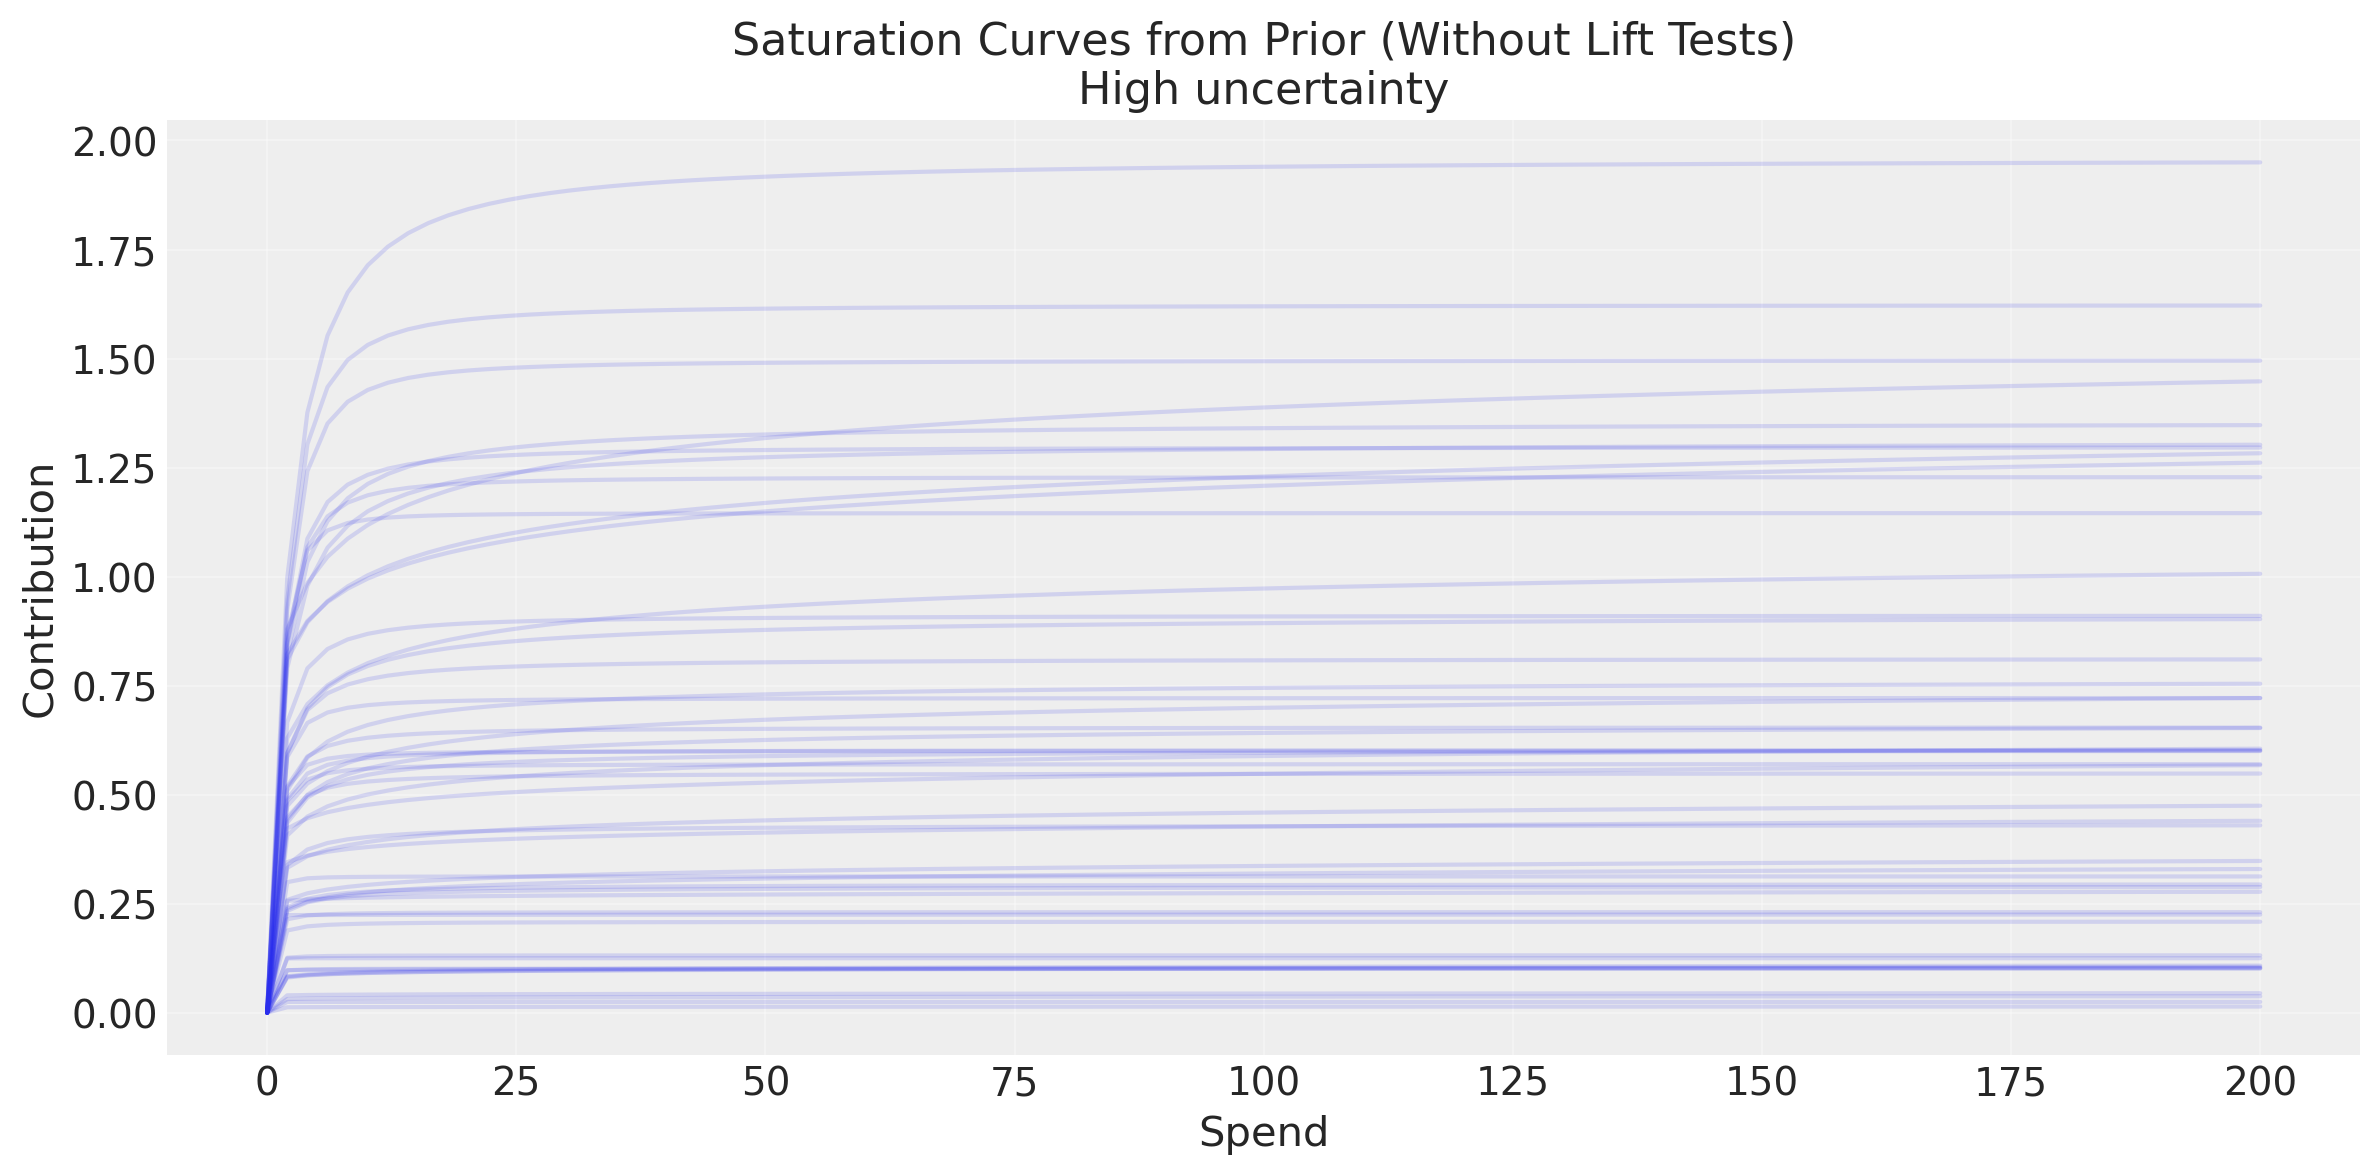

In [20]:
# Sample from the model without lift tests
with pm.Model(coords=coords) as prior_model:
    saturation_lam = pmd.HalfNormal("saturation_lam", sigma=1, dims="channel")
    saturation_beta = pmd.HalfNormal("saturation_beta", sigma=1, dims="channel")

    prior_samples = pm.sample_prior_predictive(samples=1000, random_seed=seed)

# Extract samples for channel_1
lam_prior = (
    prior_samples.prior["saturation_lam"].sel(channel="channel_1").values.flatten()
)
beta_prior = (
    prior_samples.prior["saturation_beta"].sel(channel="channel_1").values.flatten()
)

# Create spend grid
spend_grid = np.linspace(0, 200, 100)

# Plot saturation curves from prior
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for i in range(50):  # Plot 50 random draws
    lam_val = lam_prior[i]
    beta_val = beta_prior[i]
    y_curve = (
        lam_val * spend_grid**beta_val / (lam_val**beta_val + spend_grid**beta_val)
    )
    ax.plot(spend_grid, y_curve, alpha=0.15, color="C0")

ax.set_xlabel("Spend")
ax.set_ylabel("Contribution")
ax.set_title("Saturation Curves from Prior (Without Lift Tests)\nHigh uncertainty")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### With Lift Tests

Now let's see how lift tests constrain the parameter space:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [saturation_lam, saturation_beta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


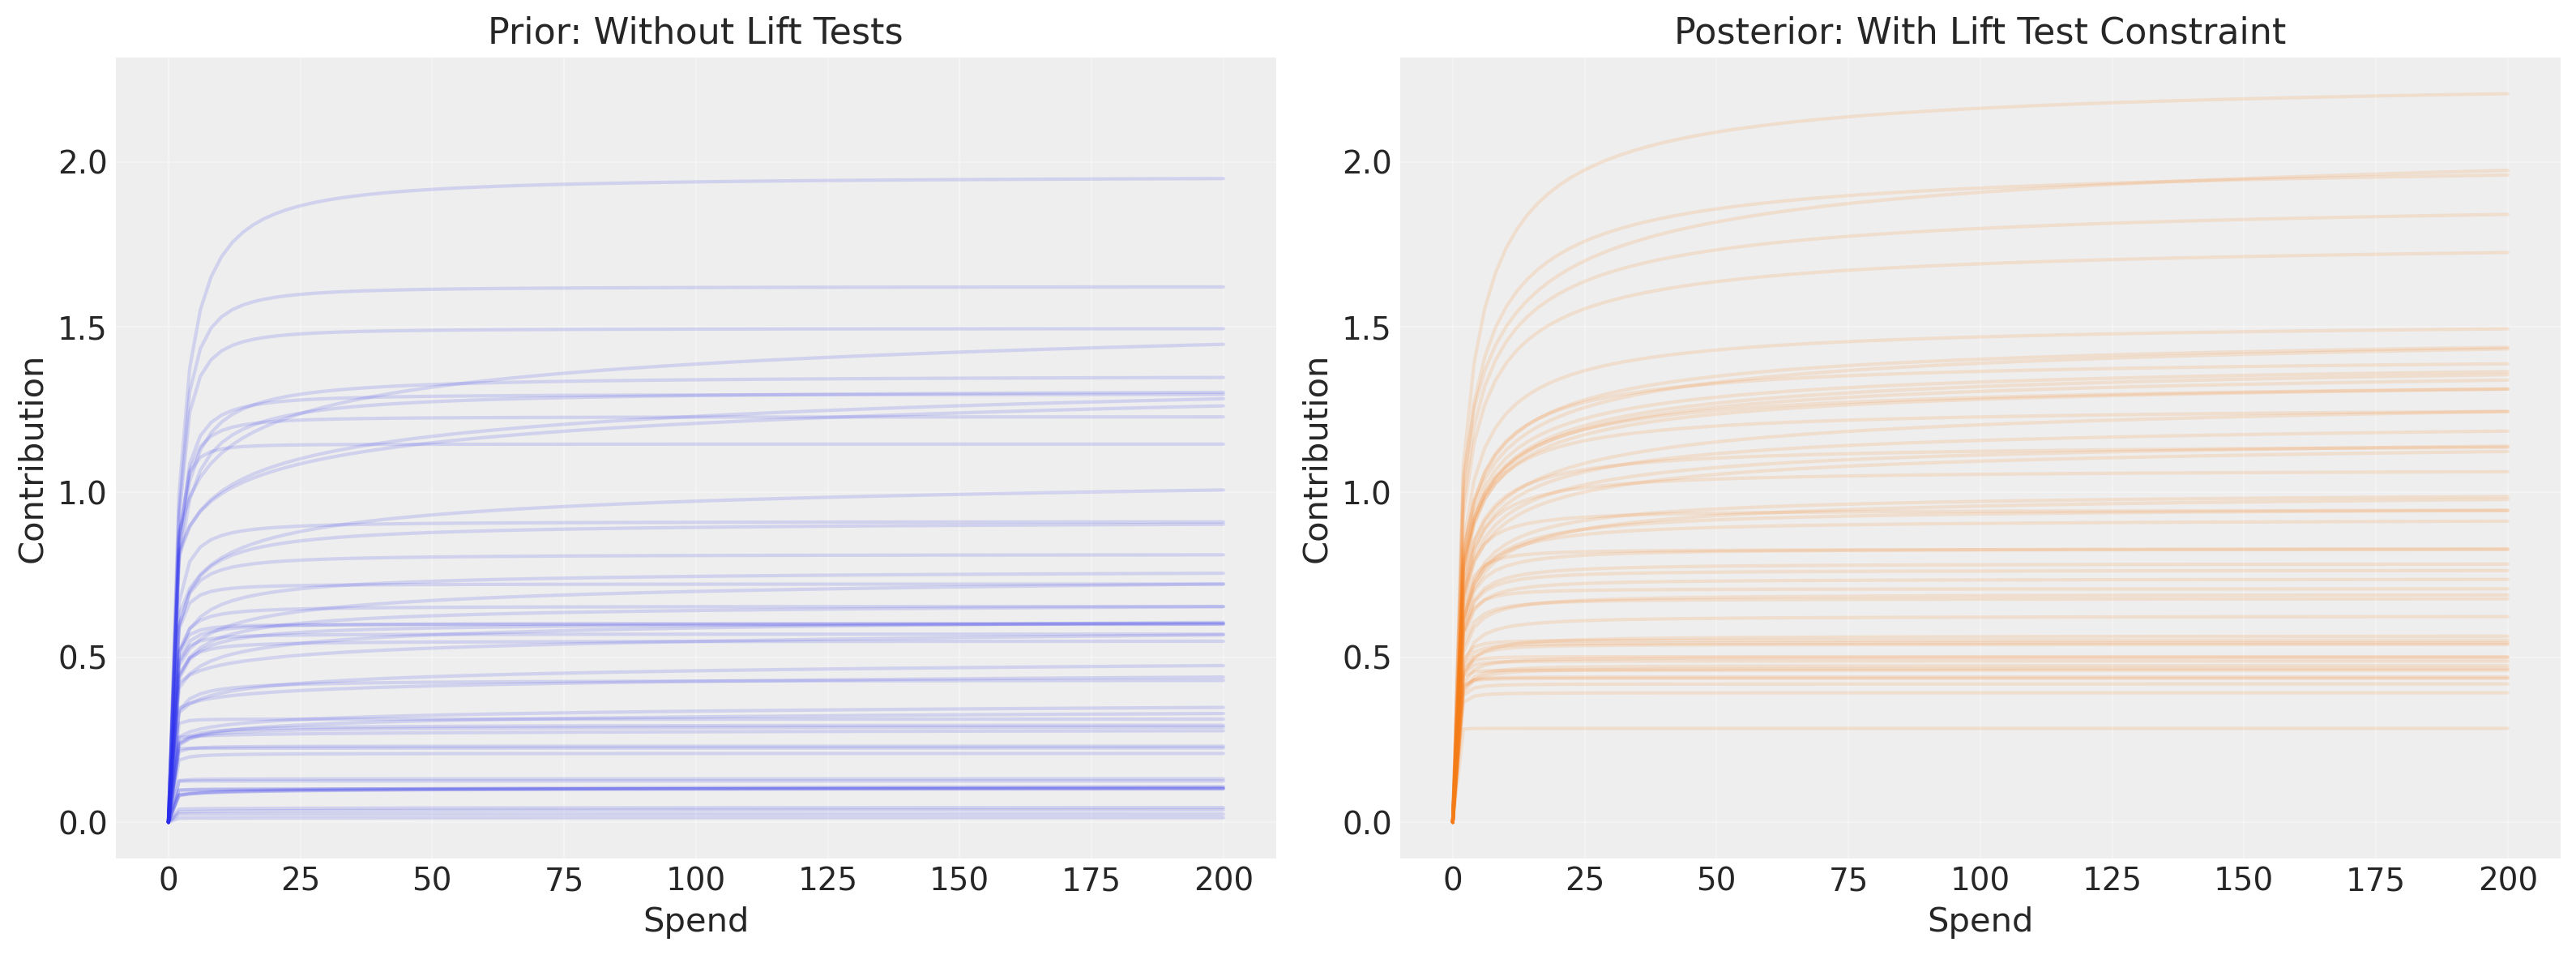

Notice how the posterior (right) shows reduced uncertainty (tighter bundle of curves)


In [21]:
# Sample from model WITH lift test
with demo_model:
    # Sample from posterior (will be constrained by lift test)
    posterior_samples = pm.sample(
        draws=1000, tune=1000, chains=4, random_seed=seed, progressbar=False
    )

# Extract samples for channel_1
lam_post = (
    posterior_samples.posterior["saturation_lam"]
    .sel(channel="channel_1")
    .values.flatten()
)
beta_post = (
    posterior_samples.posterior["saturation_beta"]
    .sel(channel="channel_1")
    .values.flatten()
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prior curves
for i in range(50):
    lam_val = lam_prior[i]
    beta_val = beta_prior[i]
    y_curve = (
        lam_val * spend_grid**beta_val / (lam_val**beta_val + spend_grid**beta_val)
    )
    axes[0].plot(spend_grid, y_curve, alpha=0.15, color="C0")

axes[0].set_xlabel("Spend")
axes[0].set_ylabel("Contribution")
axes[0].set_title("Prior: Without Lift Tests")
axes[0].grid(True, alpha=0.3)

# Posterior curves
for i in range(50):
    lam_val = lam_post[i]
    beta_val = beta_post[i]
    y_curve = (
        lam_val * spend_grid**beta_val / (lam_val**beta_val + spend_grid**beta_val)
    )
    axes[1].plot(spend_grid, y_curve, alpha=0.15, color="C1")

# Add lift test point
x_test = df_lift_test_scaled["x"].iloc[0]
delta_x_test = df_lift_test_scaled["delta_x"].iloc[0]
delta_y_test = df_lift_test_scaled["delta_y"].iloc[0]

# Compute approximate y values (using median posterior params)
lam_med = np.median(lam_post)
beta_med = np.median(beta_post)
y_before = lam_med * x_test**beta_med / (lam_med**beta_med + x_test**beta_med)
y_after = (
    lam_med
    * (x_test + delta_x_test) ** beta_med
    / (lam_med**beta_med + (x_test + delta_x_test) ** beta_med)
)

axes[1].set_xlabel("Spend")
axes[1].set_ylabel("Contribution")
axes[1].set_title("Posterior: With Lift Test Constraint")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Match y-axis scales
y_min = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

print(
    "Notice how the posterior (right) shows reduced uncertainty (tighter bundle of curves)"
)

## 7. Impact of Measurement Uncertainty (Sigma)

A critical aspect of Bayesian inference is how the uncertainty in our measurements affects the strength of the constraint they impose. The `sigma` parameter in our lift test measurements represents the standard deviation of the measurement error.

Let's explore how different levels of measurement certainty influence the posterior distribution by fitting the same model with varying sigma values:

- **Low sigma** (e.g., 0.5): High certainty - the model strongly trusts this measurement
- **Medium sigma** (e.g., 1.5): Moderate certainty - balanced influence
- **High sigma** (e.g., 3.0): Low certainty - the model is skeptical of this measurement

We'll visualize how these different uncertainty levels affect the posterior saturation curves.

In [32]:
# Define different sigma levels to explore
sigma_levels = {
    "High Certainty\n(σ=0.5)": 0.5,
    "Medium Certainty\n(σ=1.5)": 1.5,
    "Low Certainty\n(σ=3.0)": 3.0,
}

# Store posterior samples for each sigma level
posteriors = {}

for label, sigma_val in sigma_levels.items():
    print(f"Fitting model with sigma={sigma_val}...")

    # Create fresh MMM
    mmm_temp = MMM(
        date_column="date",
        channel_columns=["channel_1", "channel_2"],
        adstock=GeometricAdstock(l_max=4),
        saturation=LogisticSaturation(),
        yearly_seasonality=2,
    )

    # Build model
    mmm_temp.build_model(X, y)

    # Create lift test with this sigma value
    df_lift_test_temp = pd.DataFrame(
        {
            "channel": ["channel_1"],
            "x": [100.0],
            "delta_x": [20.0],
            "delta_y": [8.0],
            "sigma": [sigma_val],
        }
    )

    # Add lift test measurements
    mmm_temp.add_lift_test_measurements(df_lift_test_temp)

    # Sample from posterior
    with mmm_temp.model:
        idata = pm.sample(
            draws=1000, tune=1000, chains=4, random_seed=seed, progressbar=False
        )

    # Store posteriors
    posteriors[label] = {
        "lam": idata.posterior["saturation_lam"]
        .sel(channel="channel_1")
        .values.flatten(),
        "beta": idata.posterior["saturation_beta"]
        .sel(channel="channel_1")
        .values.flatten(),
    }

print("\n✓ All models fitted successfully!")

Fitting model with sigma=0.5...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.
There were 540 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fitting model with sigma=1.5...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
There were 309 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fitting model with sigma=3.0...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
There were 206 divergences after tuning. Increase `target_accept` or reparameterize.



✓ All models fitted successfully!


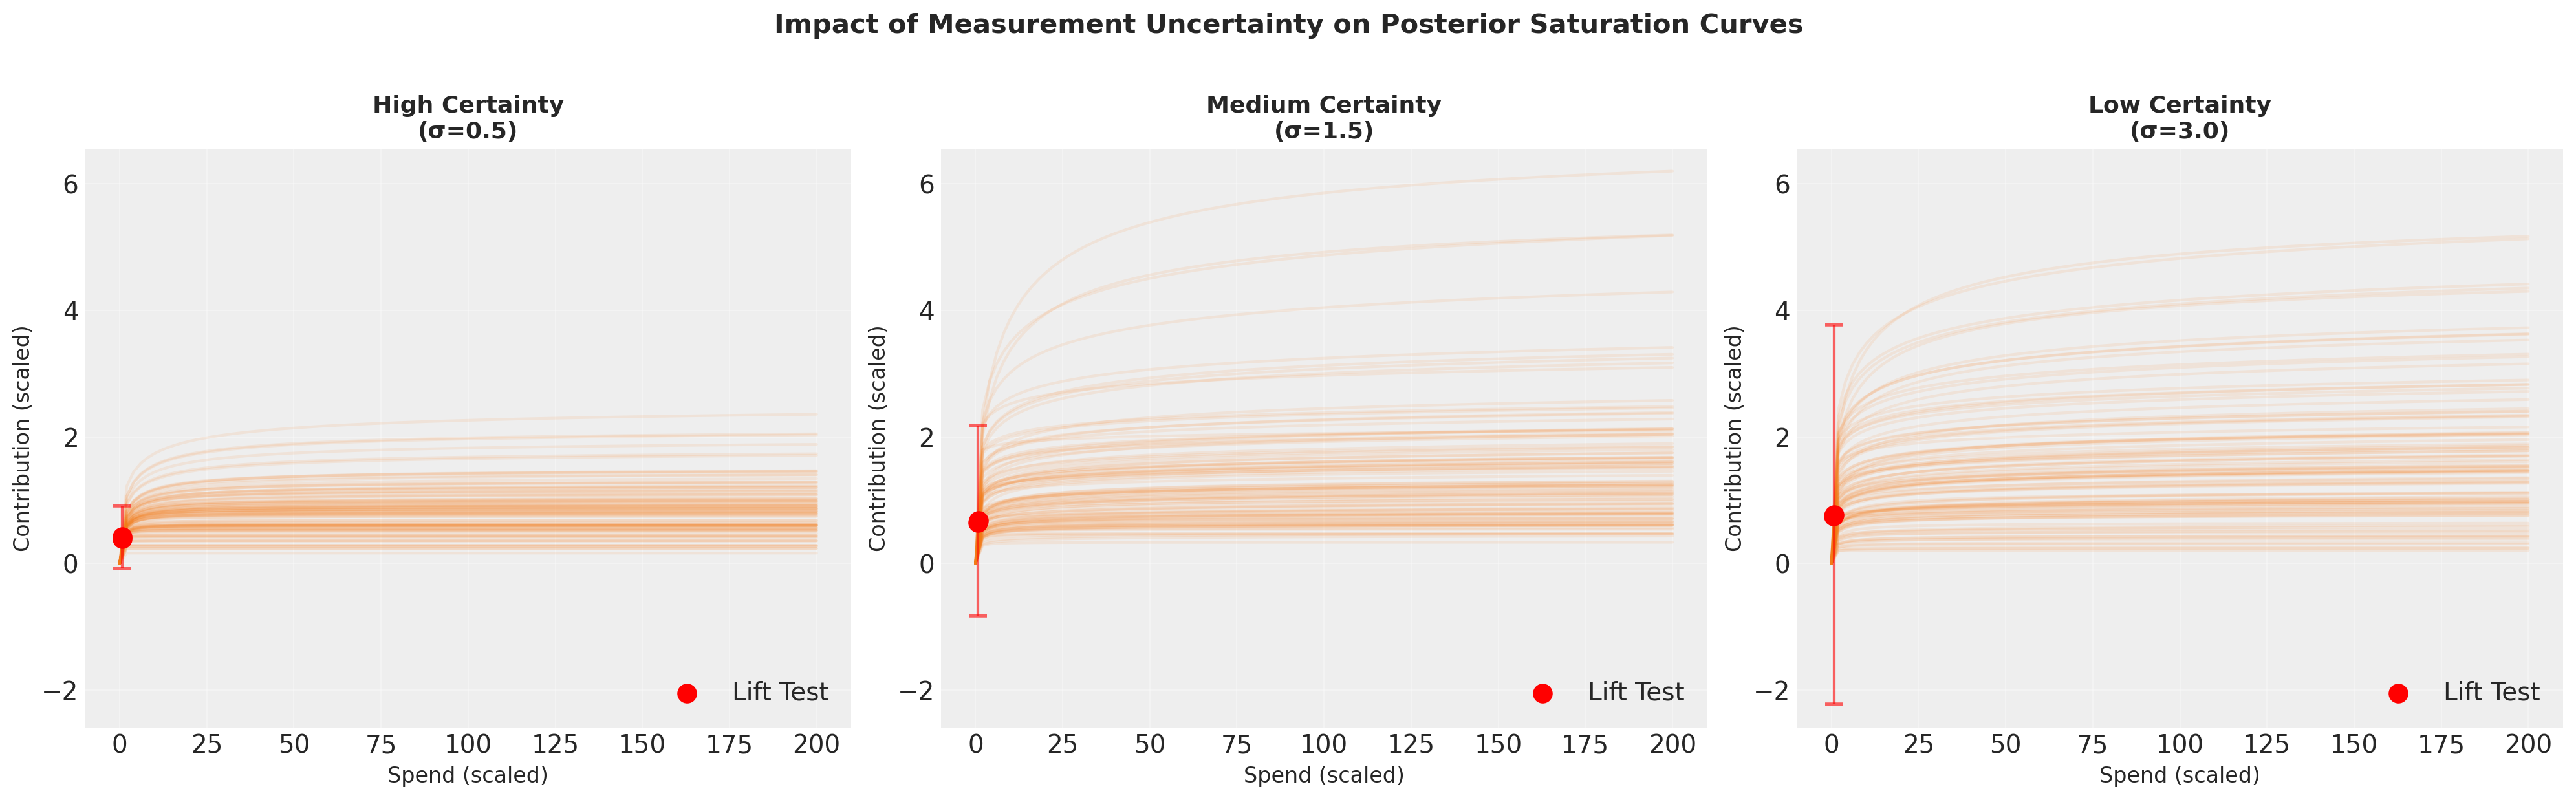

In [ ]:
# Create comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot posterior curves for each sigma level
for ax, (label, sigma_val) in zip(axes, sigma_levels.items(), strict=True):
    lam_samples = posteriors[label]["lam"]
    beta_samples = posteriors[label]["beta"]

    # Plot posterior saturation curves
    for i in range(0, len(lam_samples), len(lam_samples) // 100):  # Plot ~100 curves
        lam_val = lam_samples[i]
        beta_val = beta_samples[i]
        y_curve = (
            lam_val * spend_grid**beta_val / (lam_val**beta_val + spend_grid**beta_val)
        )
        ax.plot(spend_grid, y_curve, alpha=0.1, color="C1")

    # Plot the lift test measurement point (scaled)
    x_test = df_lift_test_scaled["x"].iloc[0]
    delta_x_test = df_lift_test_scaled["delta_x"].iloc[0]
    delta_y_test = df_lift_test_scaled["delta_y"].iloc[0]

    # Compute approximate y values using median posterior params
    lam_med = np.median(lam_samples)
    beta_med = np.median(beta_samples)
    y_before = lam_med * x_test**beta_med / (lam_med**beta_med + x_test**beta_med)
    y_after = (
        lam_med
        * (x_test + delta_x_test) ** beta_med
        / (lam_med**beta_med + (x_test + delta_x_test) ** beta_med)
    )

    # Visualize the measurement constraint
    ax.scatter(
        [x_test, x_test + delta_x_test],
        [y_before, y_after],
        color="red",
        s=100,
        zorder=5,
        label="Lift Test",
    )
    ax.errorbar(
        [x_test + delta_x_test / 2],
        [y_before + delta_y_test / 2],
        yerr=[sigma_val],
        fmt="none",
        color="red",
        capsize=5,
        capthick=2,
        alpha=0.6,
    )

    ax.set_xlabel("Spend (scaled)", fontsize=12)
    ax.set_ylabel("Contribution (scaled)", fontsize=12)
    ax.set_title(f"{label}", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

# Match y-axis scales across all plots
y_min = min(ax.get_ylim()[0] for ax in axes)
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(y_min, y_max)

plt.suptitle(
    "Impact of Measurement Uncertainty on Posterior Saturation Curves",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Understanding the Results

The visualizations above demonstrate a fundamental principle of Bayesian inference:

**The strength of evidence proportional to its certainty:**

1. **High Certainty (σ=0.5)**: The posterior is tightly constrained around the lift test measurement. The model "trusts" this data point strongly, resulting in less variance in the saturation curve predictions.

2. **Medium Certainty (σ=1.5)**: The posterior shows moderate constraint. The lift test provides useful information but doesn't dominate the prior completely.

3. **Low Certainty (σ=3.0)**: The posterior is only weakly constrained. The large uncertainty means the model remains more skeptical, and the prior has more influence.

**Practical Implications:**

- When you have high-quality lift tests with precise measurement (e.g., well-controlled experiments), use a low sigma to let the model learn strongly from them.
- When your lift test measurements are noisy or from imperfect experiments, use a higher sigma to avoid over-fitting to potentially unreliable data.
- The `sigma` parameter allows you to encode your confidence in the measurement quality, making the inference process more honest and robust.

## 8. The Complete Pipeline: MMM Integration

Now let's see the full workflow using the actual MMM `add_lift_test_measurements` method:

In [ ]:
# Create a fresh MMM with lift tests
mmm_with_lift = MMM(
    date_column="date",
    channel_columns=["channel_1", "channel_2"],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

# Build model
mmm_with_lift.build_model(X, y)

print("Before adding lift tests:")
print(f"  Free RVs: {len(mmm_with_lift.model.free_RVs)}")
print(f"  Observed RVs: {len(mmm_with_lift.model.observed_RVs)}")

# Add lift test (in ORIGINAL units, not scaled)
df_lift_test_original = pd.DataFrame(
    {
        "channel": ["channel_1"],
        "x": [100.0],
        "delta_x": [20.0],
        "delta_y": [8.0],
        "sigma": [1.5],
    }
)

mmm_with_lift.add_lift_test_measurements(df_lift_test_original)

print("\nAfter adding lift tests:")
print(f"  Free RVs: {len(mmm_with_lift.model.free_RVs)}")
print(f"  Observed RVs: {len(mmm_with_lift.model.observed_RVs)}")
print(f"  New observed RV: {mmm_with_lift.model.observed_RVs[-1].name}")

Before adding lift tests:
  Free RVs: 6
  Observed RVs: 1

After adding lift tests:
  Free RVs: 6
  Observed RVs: 2
  New observed RV: lift_measurements


### Tracing the Call Stack

Let's trace exactly what happens when `add_lift_test_measurements` is called:

mmm.add_lift_test_measurements(df_lift_test)
1. Check model has been built
2. Validate 'channel' column exists
3. Handle time-varying media (if applicable)
4. Call scale_lift_measurements()
   - scale_channel_lift_measurements()
      - Transform x and delta_x using channel_transformer
   - scale_target_for_lift_measurements()
      - Transform delta_y and sigma using target_transformer
5. Call add_lift_measurements_to_likelihood_from_saturation()
   - Handle time-varying saturation (if applicable)
   - Call add_saturation_observations()
      - Validate required columns
      - Check monotonicity
      - Call exact_row_indices() to align coordinates
      - Create x_before and x_after tensors
      - Index saturation parameters
      - Compute model_estimated_lift
      - Add Gamma observation to model